<a href="https://colab.research.google.com/github/marcuslee6/Logistics-and-Retail-Data/blob/main/Project%209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

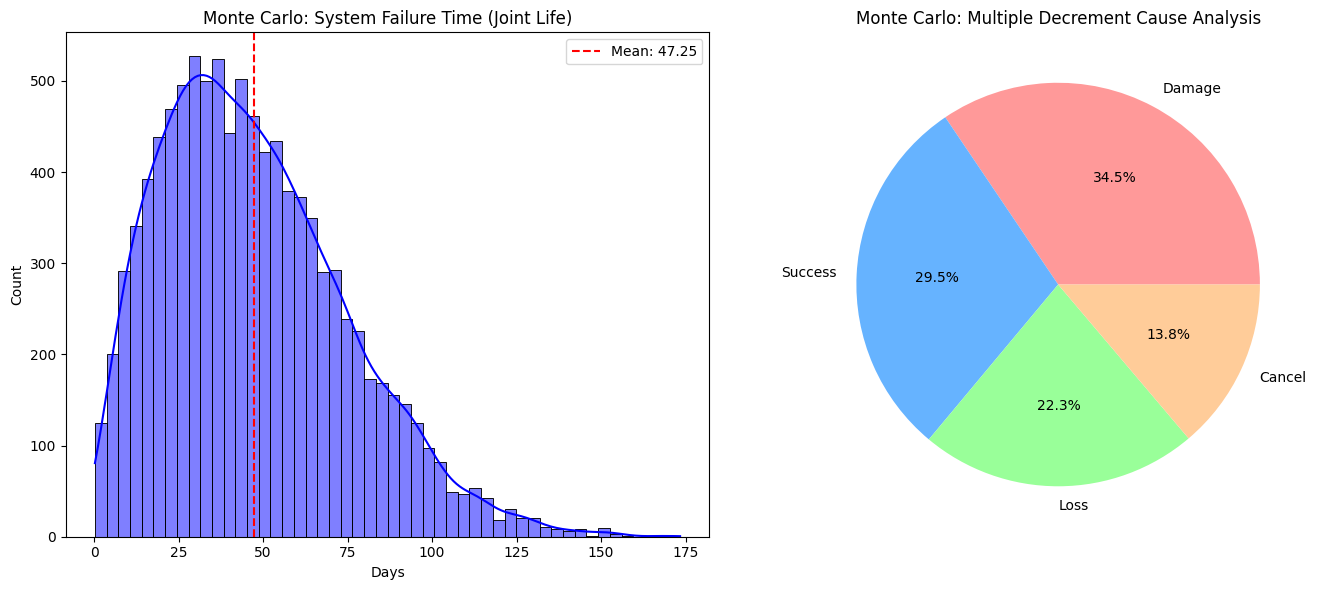

--- 蒙地卡羅模擬結果 (n=10000) ---
預期系統停機時間 (Expected System Life): 47.25 days
訂單最終狀態概率分布:
Event_Cause
Damage     0.3445
Success    0.2948
Loss       0.2226
Cancel     0.1381
Name: proportion, dtype: float64


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 設定模擬參數
n_simulations = 10000 # 蒙地卡羅模擬次數
np.random.seed(42)

# ---------------------------------------------------------
# 1. Joint Life Simulation (物流線組件故障)
# ---------------------------------------------------------
# 假設系統有三個串聯組件：馬達 (Motor), 傳感器 (Sensor), 軸承 (Bearing)
# 使用 Weibull 分佈模擬每個組件的故障時間
motor_lifespan = np.random.weibull(2.0, n_simulations) * 100
sensor_lifespan = np.random.weibull(1.5, n_simulations) * 80
bearing_lifespan = np.random.weibull(2.2, n_simulations) * 120

# Joint Life (串聯系統)：只要一個壞，整條線就停
system_failure_time = np.minimum.reduce([motor_lifespan, sensor_lifespan, bearing_lifespan])

# ---------------------------------------------------------
# 2. Multiple Decrement Simulation (訂單流失模擬)
# ---------------------------------------------------------
# 模擬 10,000 個訂單，每個訂單會面臨三種「減額原因」的競爭
# 我們模擬每種原因預計發生的時間，最先發生的就是該訂單的「死因」
damage_time = np.random.exponential(50, n_simulations) # 損毀發生時間
loss_time = np.random.exponential(80, n_simulations) # 遺失發生時間
cancel_time = np.random.exponential(120, n_simulations) # 取消發生時間
success_time = np.full(n_simulations, 30) # 正常送達時間 (假設30天內沒壞就成功)

# 找出哪個事件最先發生
results = pd.DataFrame({
'Damage': damage_time,
'Loss': loss_time,
'Cancel': cancel_time,
'Success': success_time
})

df_sim = pd.DataFrame()
df_sim['Time_to_Event'] = results.min(axis=1)
df_sim['Event_Cause'] = results.idxmin(axis=1)

# ---------------------------------------------------------
# 3. 統計分析與視覺化
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# 圖 A: 系統壽命的蒙地卡羅分佈 (Joint Life)
plt.subplot(1, 2, 1)
sns.histplot(system_failure_time, kde=True, color='blue', bins=50)
plt.axvline(np.mean(system_failure_time), color='red', linestyle='--', label=f'Mean: {np.mean(system_failure_time):.2f}')
plt.title('Monte Carlo: System Failure Time (Joint Life)')
plt.xlabel('Days')
plt.legend()

# 圖 B: 多重減額原因佔比 (Multiple Decrement Outcomes)
plt.subplot(1, 2, 2)
df_sim['Event_Cause'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Monte Carlo: Multiple Decrement Cause Analysis')
plt.ylabel('')

plt.tight_layout()
plt.show()

# 4. 精算指標輸出
print(f"--- 蒙地卡羅模擬結果 (n={n_simulations}) ---")
print(f"預期系統停機時間 (Expected System Life): {np.mean(system_failure_time):.2f} days")
print(f"訂單最終狀態概率分布:\n{df_sim['Event_Cause'].value_counts(normalize=True)}")



